In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# --- 1. Gerar Dados de Treinamento ---
np.random.seed(42)
tf.random.set_seed(42)
num_samples = 1000
angles_train = np.random.uniform(0, 6 * np.pi, num_samples).reshape(-1, 1)


In [3]:

# Calcular o cosseno dos ângulos
cos_values_train = np.cos(angles_train)

# Adicionar ruído gaussiano
noise = np.random.normal(0, 0.01, cos_values_train.shape)
cos_values_train += noise


In [4]:
# --- 2. Definir o Modelo de Rede Neural ---
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(50, activation='tanh'),
    tf.keras.layers.Dense(50, activation='tanh'),
    tf.keras.layers.Dense(50, activation='tanh'),
    tf.keras.layers.Dense(1)
])

In [5]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse')


In [6]:
# --- 3. Treinar o Modelo ---
history = model.fit(angles_train, cos_values_train,
                    epochs=1000,
                    batch_size=16,
                    verbose=0)


In [7]:
# --- 4. Gerar Dados de Teste ---
angles_test = np.linspace(0, 6 * np.pi, 100).reshape(-1, 1)
cos_values_true = np.cos(angles_test)


In [8]:
# --- 5. Fazer Previsões ---
cos_values_predicted = model.predict(angles_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


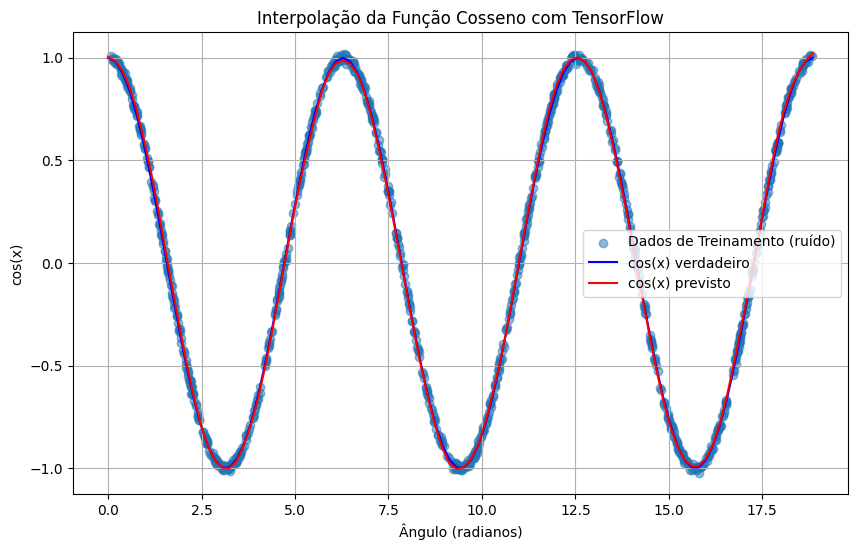

In [9]:
# --- 6. Visualizar os Resultados ---
plt.figure(figsize=(10, 6))
plt.scatter(angles_train, cos_values_train, label='Dados de Treinamento (ruído)', alpha=0.5)
plt.plot(angles_test, cos_values_true, label='cos(x) verdadeiro', color='blue')
plt.plot(angles_test, cos_values_predicted, label='cos(x) previsto', color='red')
plt.xlabel('Ângulo (radianos)')
plt.ylabel('cos(x)')
plt.title('Interpolação da Função Cosseno com TensorFlow')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# --- 7. Relatar o Erro Quadrático Médio (MSE) ---
mse = tf.reduce_mean(tf.square(cos_values_true - cos_values_predicted))
print(f"Erro Quadrático Médio nos Dados de Teste: {mse.numpy():.6f}")

Erro Quadrático Médio nos Dados de Teste: 0.000186
